# **Домашнее задание 2. Распределенное обучение LLM**

In [1]:
%pip install numpy matplotlib pandas

   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.3 MB 5.2 MB/s eta 0:00:03
   ---- ----------------------------------- 1.3/12.3 MB 5.1 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/12.3 MB 5.2 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.3 MB 5.1 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.3 MB 4.8 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.3 MB 5.0 MB/s eta 0:00:02
   ----------------------- ---------------- 7.3/12.3 MB 5.1 MB/s eta 0:00:01
   ------------------------- -------------- 7.9/12.3 MB 4.9 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.3 MB 4.9 MB/s eta 0:00:01
   --------------------------------- ------ 10.2/12.3 MB 5.0 MB/s eta 0:00:01
   ------------------------------------ --- 11.3/12.3 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 5.0 MB/s  0:00:02
   ---

In [10]:
# === Парсер логов обучения ===
import ast
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

LOG_DIR = Path('outputs')

# Регулярка: ищем подстроку вида {...'global_step': N, ...}
_DICT_RE = re.compile(r"\{[^{}]*'global_step'[^{}]*\}")
_PPL_RE  = re.compile(r"epoch\s+(\d+):\s+perplexity:\s+([\d.eE+\-inf]+)\s+eval_loss:\s+([\d.eE+\-]+)")


def parse_log(path):
    steps, evals = [], []
    if not Path(path).exists():
        print(f'[warn] {path} not found')
        return pd.DataFrame(), pd.DataFrame()

    with open(path, 'r', errors='replace') as f:
        for line in f:
            m = _DICT_RE.search(line)
            if m:
                try:
                    rec = ast.literal_eval(m.group(0))
                    if isinstance(rec, dict) and 'global_step' in rec:
                        steps.append(rec)
                        continue
                except (ValueError, SyntaxError):
                    pass

            m = _PPL_RE.search(line)
            if m:
                evals.append({
                    'epoch': int(m.group(1)),
                    'perplexity': float(m.group(2)),
                    'eval_loss': float(m.group(3)),
                })

    return pd.DataFrame(steps), pd.DataFrame(evals)


def load_runs(name_to_file):
    """name_to_file: {label: filename_in_outputs/}.

    Returns dict label -> (steps_df, eval_df).
    """
    runs = {}
    for label, fname in name_to_file.items():
        s, e = parse_log(LOG_DIR / fname)
        runs[label] = (s, e)
        if not s.empty:
            print(f'{label:>32s}: {len(s):4d} step-records, {len(e)} eval-records')
        else:
            print(f'{label:>32s}: NO DATA (file missing or unparseable)')
    return runs


def plot_dynamics(runs, title_prefix='', smooth=1):
    metrics = [
        ('running_loss',  'Train loss (running)',  'loss'),
        ('tokens_per_s',  'Throughput (tok/s)',    'tok/s'),
        ('peak_alloc_gb', 'Peak GPU memory (GB)',  'GB'),
        ('lr',            'Learning rate',         'lr'),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes = axes.flatten()

    for ax, (col, ylabel, _) in zip(axes, metrics):
        for label, (s, _) in runs.items():
            if s.empty or col not in s.columns:
                continue
            x = s['global_step']
            y = s[col]
            if smooth > 1 and col == 'running_loss':
                y = y.rolling(smooth, min_periods=1).mean()
            ax.plot(x, y, label=label, linewidth=1.6, alpha=0.9)
        ax.set_xlabel('global_step')
        ax.set_ylabel(ylabel)
        ax.grid(linestyle='--', alpha=0.4)
        ax.legend(fontsize=8)
        if col == 'tokens_per_s':
            ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    fig.suptitle(f'{title_prefix} — динамика обучения', fontsize=13)
    fig.tight_layout()
    plt.show()


def plot_eval(runs, title_prefix=''):

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for label, (_, e) in runs.items():
        if e.empty:
            continue
        axes[0].plot(e['epoch'], e['eval_loss'],   'o-', label=label)
        axes[1].plot(e['epoch'], e['perplexity'], 'o-', label=label)
    axes[0].set(xlabel='epoch', ylabel='eval_loss',  title='Eval loss')
    axes[1].set(xlabel='epoch', ylabel='perplexity', title='Eval perplexity')
    axes[1].set_yscale('log')
    for ax in axes:
        ax.grid(linestyle='--', alpha=0.4)
        ax.legend(fontsize=9)
    fig.suptitle(f'{title_prefix} — eval', fontsize=13)
    fig.tight_layout()
    plt.show()


## Задание 1. Single-GPU baseline

In [5]:
# подсчёт grad-accum-steps
!bash get_last_dimension.sh  --seq_len 512 --local_batch_size 16  --dp_size 1  --global_batch_size 131072

16


In [11]:
!bash 1_table.sh

--- Peak memory (GB)	Throughput (tok/s)	Val PPL ---
fp32           	peak=12.971665920000001 GB	throughput=641778.4 tok/s	Val PPL=280.02800125775974
bf16           	peak=6.557669888 GB	throughput=2691058.3 tok/s	Val PPL=1003.7306589435354
bf16-ckpt      	peak=4.107745792 GB	throughput=2185654.0 tok/s	Val PPL=1003.5837345628263


                            fp32:   85 step-records, 1 eval-records
                            bf16:   85 step-records, 1 eval-records
                       bf16+ckpt:   85 step-records, 1 eval-records


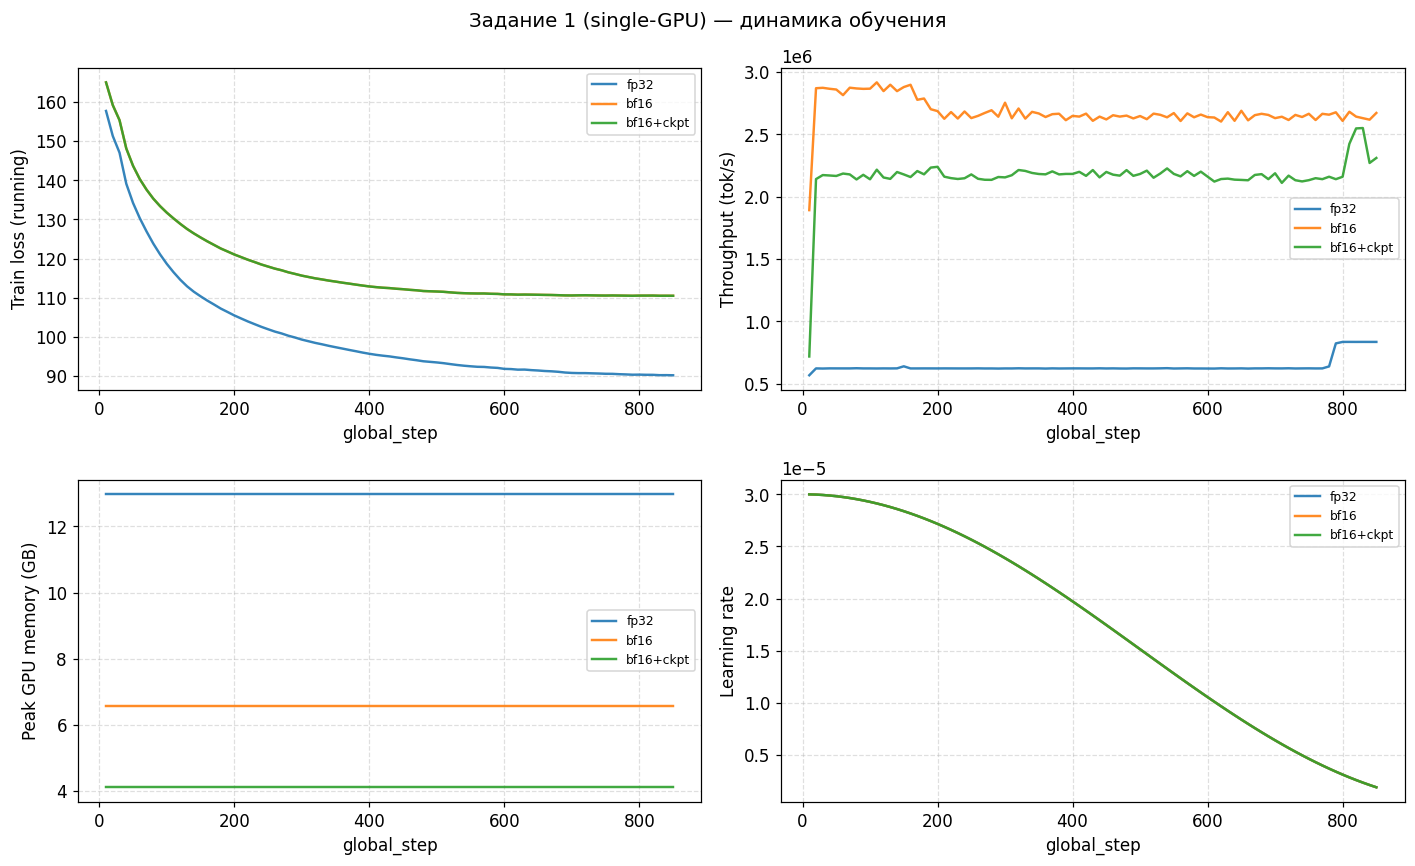

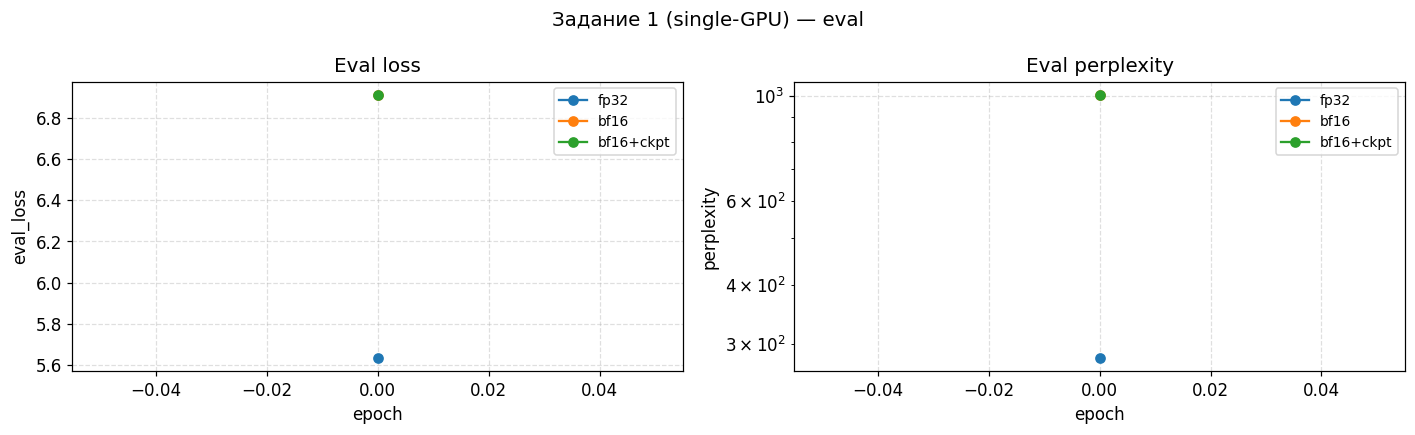

In [12]:
runs_t1 = load_runs({
    'fp32':       'baseline-fp32.log',
    'bf16':       'baseline-bf16.log',
    'bf16+ckpt':  'baseline-bf16-ckpt.log',
})
plot_dynamics(runs_t1, title_prefix='Задание 1 (single-GPU)', smooth=3)
plot_eval(runs_t1, title_prefix='Задание 1 (single-GPU)')

| Config | Peak mem/GPU (GB) | Throughput (tok/s) | Val PPL |
|---|---|---|---|
| fp32 | 12.971665920000001 | 641778.4  | 280.02800125775974|
| bf16 | 6.557669888 | 2691058.3| 1003.7306589435354 |
| bf16-ckpt | 4.107745792 | 2185654.0 | 1003.5837345628263 |

### 1.A (2 балла)

Память при переходе с fp32 на bf16 уменьшилась на 6.41 GB. Pythia-160m имеет ~160M параметров. Посчитайте, сколько памяти занимают только параметры в fp32 и в bf16. Объясните, почему реальная разница 6.41 GB отличается от разницы только по параметрам.
#### Ответ  
$$\text{fp32: }160\text{ М} \cdot 4 \text{ байта}=640\text{ M байт} \approx 0.6\text{ GB}$$
$$\text{bf16: }160\text{ M} \cdot 2 \text{ байта}=320\text{ М байт} \approx 0.3\text{ GB}$$
Того разница памяти по параметрам примерно равна $0.3$ GB. Но реальная разница состоит также из размера слоев активации, градиентов, буферов, optimizer states - потому и такая разница.

### 1.B (2 балла)

Throughput при включении activation checkpointing (он же gradient checkpointing) изменился на 18.78%. Засчет чего именно? Activation checkpointing экономит память - что является ценой за эту экономию?  
#### Ответ  
Activation checkpointing не сохраняет промежуточные активации в память, сохраняя лишь активации на чекпоинтах. Когда нужен backward - активации пересчитываются повторным forward. Естественно, из-за этого тратятся FLOPs на дополнительные вычисления. Без activation checkpointing - $1 \text{ forward} + 1 \text{ backward}$, а с - $2 \text{ forward} + 1 \text{ backward}$. Известно, что по FLOPs $2\text{ forward} \sim 1\text{ backward}$. Того отношение $3:4$, то есть замедление $\sim 25$%. На практике меньше из-за kernel fusion + чекпоинты не на каждом слое.
### 1.C (1 балл)

Val PPL во всех трех конфигах - совпадают ли они? Если есть расхождение $> 1$ единицы - это ожидаемо или нет? Activation checkpointing влияет на val PPL? Должен ли влиять теоретически?  
#### Ответ  
Между bf16 и bf16-ckpt разница небольшая, $< 1$. Но вот между fp32 и всеми остальными разница  коллосальная. Конечно, из-за неиспользования torch AMP - банально мантисса слишком неточна. Activasion checkpointing не должен влиять на val PPL, но, те м не менее, влияет - вероятно, из-за деталей реализации в CUDA. 

## Задание 2. FSDP: стратегии шардирования. 

In [7]:
# Подсчёт grad-accum-steps
!bash get_last_dimension.sh  --seq_len 512 --local_batch_size 16  --dp_size 4  --global_batch_size 131072

4


In [8]:
!bash 2_table.sh


===== RESULTS =====

--- Strategy	Peak mem/GPU (GB)	Throughput (tok/s)	Val PPL ---
no_shard       	peak=9.909930496000001 GB	throughput=1606555.1 tok/s	Val PPL=1002.5553878489476
shard_grad_op  	peak=9.252408832 GB	throughput=1141930.9 tok/s	Val PPL=1002.6839930699157
full_shard     	peak=9.087870464 GB	throughput=1052492.7 tok/s	Val PPL=1002.5740321931294


                        no_shard:  340 step-records, 1 eval-records
                   shard_grad_op:  340 step-records, 1 eval-records
                      full_shard:  340 step-records, 1 eval-records


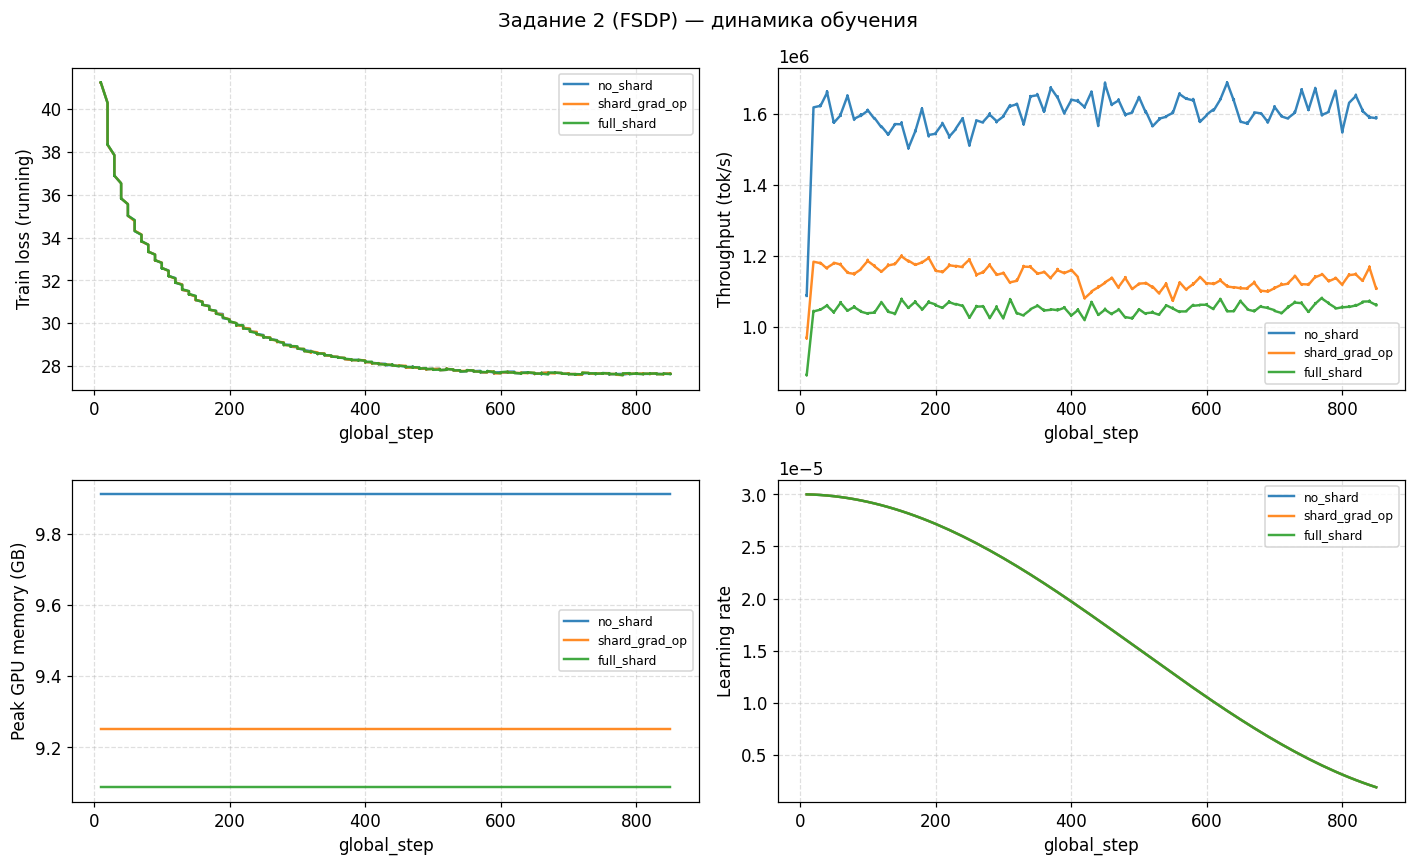

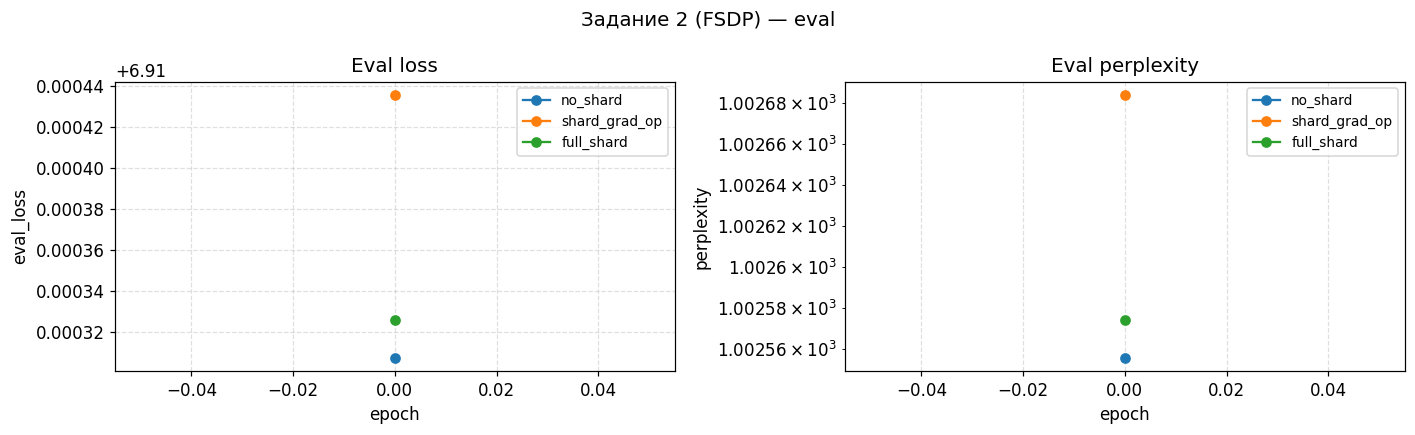

In [13]:
runs_t2 = load_runs({
    'no_shard':    'fsdp-no_shard.log',
    'shard_grad_op':       'fsdp-shard_grad_op.log',
    'full_shard':  'fsdp-full_shard.log',
})
plot_dynamics(runs_t2, title_prefix='Задание 2 (FSDP)', smooth=3)
plot_eval(runs_t2, title_prefix='Задание 2 (FSDP)')

| Strategy | Peak mem/GPU (GB) | Throughput (tok/s) | Val PPL |
|---|---|---|---|
| NO_SHARD | 9.909930496000001 | 1606555.1 | 1002.5553878489476 |
| SHARD_GRAD_OP | 9.252408832 | 1141930.9| 1002.6839930699157 |
| FULL_SHARD | 9.087870464 | 1052492.7 | 1002.5740321931294 |

### 2.A (2 балла)

Для каждой стратегии рассчитайте теоретический расход памяти на каждую GPU (считайте, что optimizer states хранятся в fp32). Сравните теоретические значения с реальными замерами из таблицы. Насколько они близки и чем объясняется расхождение?

#### Ответ

По условию optimizer states хранятся в fp32.

На каждый параметр потенциально хранится:
- weight (bf16): 2 байта
- gradient (bf16): 2 байта  
- master weight (fp32): 4 байта
- Adam momentum $m$ (fp32): 4 байта
- Adam variance $v$ (fp32): 4 байта

Итого full-копии: $16 \cdot 160 \cdot 10^6$ байт $= 2.56$ GB.

**1. NO_SHARD** - ничего не шардится, каждая GPU держит full-копию:
$$\text{mem} = 2.56 \text{ GB}$$

**2. SHARD_GRAD_OP** - параметры full, градиенты + optimizer state шардятся на $4$. Положим $P := 160 \cdot 10^6$
$$\text{mem} = 2P + \frac{2P + 4P + 4P + 4P}{4} = 2P + \frac{14P}{4} = 320 + 560 = 880 \text{ MB} \approx 0.88 \text{ GB}$$

**3. FULL_SHARD** - всё шардится на $N$:
$$\text{mem} = \frac{16P}{N} = \frac{2560}{4} = 640 \text{ MB} \approx 0.64 \text{ GB}$$

#### Сравнение с реальностью

| Strategy | Теория | Реальный peak | Δ |
|---|---|---|---|
| NO_SHARD | 2.56 GB | 9.91 GB | ~7.35 GB |
| SHARD_GRAD_OP | 0.88 GB | 9.25 GB | ~8.37 GB |
| FULL_SHARD | 0.64 GB | 9.09 GB | ~8.45 GB |

Реальные замеры **значительно выше** теоретических - расхождение ~7–8 GB во всех конфигах. Объясняется это так:

1. **Активации** - основная неучтённая статья. При `batch_size=16`, `seq_len=512`, Активации в FSDP не шардятся, поэтому они одинаковы во всех трёх конфигах и добавляют примерно одинаковый "хвост".
2. **Communication buffers** - для all-gather полных параметров в FULL_SHARD и reduce-scatter градиентов нужны временные буферы.
3. **DDP gradient bucketing** - в NO_SHARD используется DDP с `bucket_cap_mb=500`, что создаёт дополнительные буферы для bucket-агрегации градиентов.
4. **--no-compile** заставляет хранить весь граф вычислений.

**Относительная экономия** теоретическая (2.56 → 0.64, экономия 1.92 GB или 75%) и реальная (9.91 → 9.09, экономия 0.82 GB или 8%) сильно отличаются. Причина - активации, и шардирование параметров/градиентов/оптимизатора экономит лишь ту часть, которая в активациях не учтена. Для большой модели (где параметры/optimizer/градиенты сопоставимы с активациями или больше) FSDP даёт несравнимо большую относительную выгоду.

---

### 2.B (2 балла)

Как изменился throughput при FULL_SHARD по сравнению с NO_SHARD?

#### Ответ

Throughput упал с **1 606 555** до **1 052 493** tok/s, то есть на **−34.5%**.

#### Какие коммуникации происходят

**NO_SHARD** (обычный DDP):
- Forward: коммуникаций нет, у каждой GPU полная копия модели.
- Backward: **1× all-reduce градиентов** по всем GPU (агрегация и усреднение).
- Optimizer step: локально, веса синхронизированы благодаря all-reduce.

**SHARD_GRAD_OP** (≈ ZeRO-2):
- Forward: коммуникаций нет, параметры полные.
- Backward: **1× reduce-scatter градиентов** (каждая GPU получает свой шард усреднённого градиента).
- Optimizer step: локально, на своём шарде.
- Перед следующим forward: **1× all-gather параметров** (или их апдейтов) для синхронизации полных весов.

**FULL_SHARD** (≈ ZeRO-3):
- Forward: для каждого FSDP-блока - **all-gather параметров** перед вычислением, потом сразу освобождение шарда.
- Backward: для каждого блока - снова **all-gather параметров** + **reduce-scatter градиентов**.
- Итого: **2× all-gather (forward + backward) + 1× reduce-scatter**.

#### Объяснение падения throughput

FULL_SHARD добавляет существенно больше коммуникаций, чем NO_SHARD:
- появился отдельный all-gather на forward (которого в DDP нет вообще);
- 1 all-reduce заменяется на all-gather + reduce-scatter (по объёму данных эквивалентно, но это 2 синхронизации вместо 1, плюс больше kernel launches);
- коммуникация выполняется **на каждый блок** трансформера, а не одной большой операцией в конце backward.

На маленькой модели Pythia-160M compute занимает мало времени, и коммуникация **плохо перекрывается с вычислениями** (пока идёт all-gather, считать особо нечего). Поэтому overhead виден как падение throughput на 34.5%.

#### Что было бы для модели в 10× больше (~1.6B)

Здесь меняется соотношение compute/communication:
- **Compute** масштабируется линейно с числом параметров (×10).
- **Communication** тоже масштабируется линейно с параметрами (×10), но **отлично перекрывается** с вычислениями в FSDP - пока все GPU считают forward текущего блока, в фоне идёт all-gather следующего.
- При больших моделях NO_SHARD просто **перестаёт помещаться в память** одной GPU.

**Прогноз:** разница в throughput между FULL_SHARD и NO_SHARD сократится до 5–15% (вместо текущих ~35%), а при дальнейшем масштабировании NO_SHARD становится невозможным. Именно поэтому FSDP создан для больших моделей - на маленькой Pythia-160M он выглядит как "плата без выгоды".

---

### 2.C (1 балл)

Val PPL между тремя конфигами - совпадают ли они? Должны ли совпадать теоретически?

#### Ответ

Val PPL: **1002.56 / 1002.68 / 1002.57** - расхождение макс **0.13** PPL, то есть < 1.

**Теоретически - должны совпадать точно.** FSDP - это математически эквивалентная реорганизация data-parallel обучения. Шардирование параметров, градиентов и optimizer states влияет только на то, **где хранятся** тензоры, а не на то, **что вычисляется**. Forward даёт идентичные активации, all-reduce / (reduce-scatter + all-gather) градиентов даёт идентичные усреднённые градиенты, апдейты весов идентичны → loss и PPL должны совпадать.

**Расхождение 0.13 - это численный шум.** Гипотеза: разный **порядок суммирования** в коммуникациях. All-reduce в DDP и reduce-scatter в FSDP редуцируют тензоры по GPU в разном порядке. В bf16 (всего 7 бит мантиссы) ассоциативность сложения нарушается из-за округления: $(a+b)+c \neq a+(b+c)$ в плавающей точке. После многих итераций мелкие различия накапливаются и дают расхождение в loss на уровне 4-го знака после запятой → расхождение в PPL на ~0.1.


### Задание 3. CPU Offload

In [9]:
!bash 3_table.sh


===== RESULTS =====


--- Strategy	Peak mem/GPU (GB)	Throughput (tok/s) ---
full-shard-noCPU	peak=6.1391851520000005 GB	throughput=1171120.5 tok/s
full-shard-CPU 	peak=5.4851599360000005 GB	throughput=619183.1 tok/s
full-shard-CPU-checkpointing	peak=2.967336448 GB	throughput=545250.8 tok/s


                full-shard-noCPU:  170 step-records, 1 eval-records
                  full-shard-CPU:  170 step-records, 1 eval-records
    full-shard-CPU-checkpointing:  170 step-records, 1 eval-records


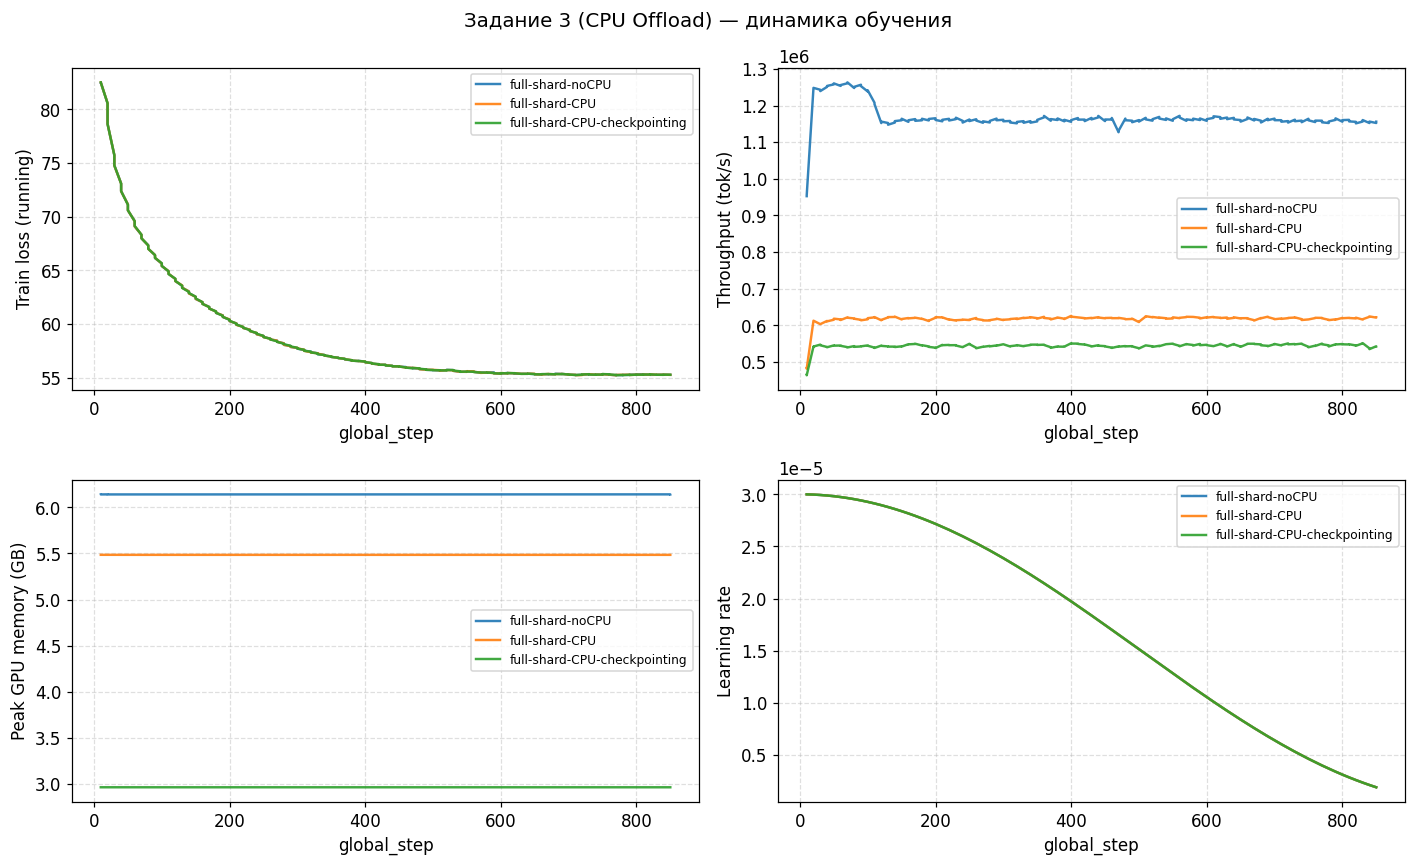

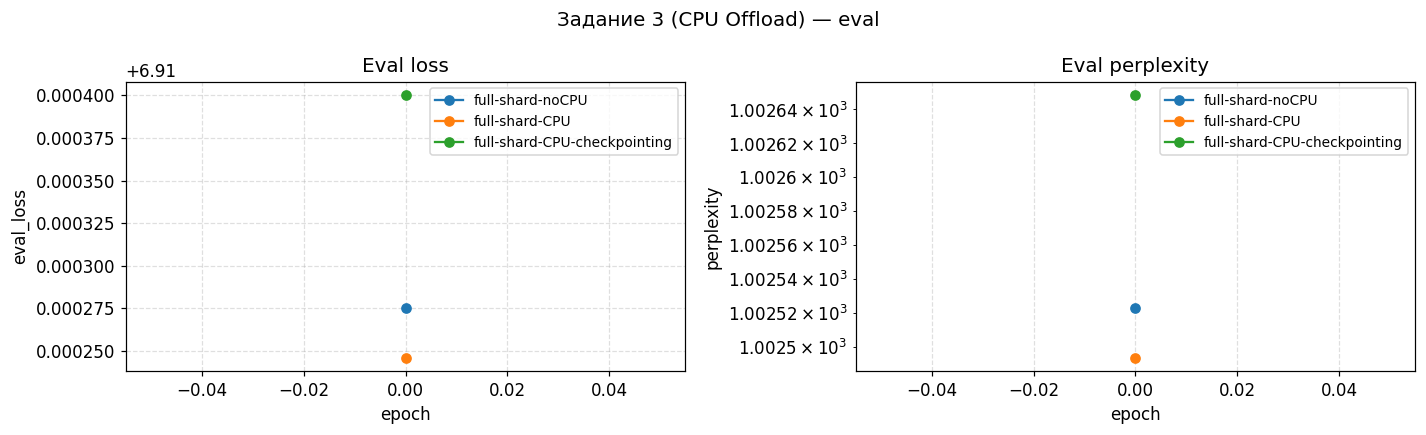

In [15]:
runs_t3 = load_runs({
    'full-shard-noCPU':    'fsdp-full-shard-noCPU.log',
    'full-shard-CPU':       'fsdp-full-shard-CPU.log',
    'full-shard-CPU-checkpointing':  'fsdp-full-shard-CPU-checkpointing.log',
})
plot_dynamics(runs_t3, title_prefix='Задание 3 (CPU Offload)', smooth=3)
plot_eval(runs_t3, title_prefix='Задание 3 (CPU Offload)')

| Strategy	 | Peak mem/GPU (GB) | Throughput (tok/s) |
|---|---|---|
| full-shard-noCPU | 6.1391851520000005 | 1171120.5  |
| full-shard-CPU | 5.4851599360000005 | 619183.1|
| full-shard-CPU-checkpointing | 2.967336448 | 545250.8 |

### 3.A (2 балла)
Как изменилась пиковая расходуемая память на GPU при включении CPUOffload? Объясните, какие данные offload перемещает на CPU и когда они возвращаются на GPU. 
#### Ответ
Изменение памяти: пиковая память на GPU снизилась с 6.139 ГБ до 5.485 ГБ, то есть примерно на 0.654 ГБ (~10.7%).
Что именно offload переносит на CPU. При использовании CPUOffload(offload_params=True) в FSDP на CPU перемещаются шардированные параметры модели и (по умолчанию вместе с ними) соответствующие градиенты после их редукции. То есть в "состоянии покоя" между шагами вычислений на GPU не лежат ни веса, ни их градиенты - они хранятся в pinned-памяти CPU. Состояния оптимизатора (моменты Adam и т.п.) при этом тоже фактически живут на CPU, потому что шаг оптимизатора выполняется над параметрами, которые уже там находятся.
Когда данные возвращаются на GPU. FSDP работает по принципу "собрать → посчитать → выбросить":

Перед forward-проходом конкретного FSDP-юнита его шард параметров копируется с CPU на GPU, затем выполняется all_gather по rank'ам, чтобы собрать полный набор весов этого слоя. После того как forward по слою завершён, полный тензор отбрасывается, и шард уезжает обратно на CPU.
Перед backward-проходом того же юнита процедура повторяется: шард снова поднимается на GPU, делается all_gather, считаются градиенты, выполняется reduce_scatter, и итоговый шард градиентов вместе с шардом параметров уходит обратно на CPU.
Шаг оптимизатора выполняется на CPU над параметрами и градиентами, которые уже там лежат, и обновлённые параметры остаются в CPU-памяти до следующей итерации.

Экономия скромная (≈10%), потому что в этом запуске основной вклад в пиковую память дают активации, а не параметры - модель относительно небольшая, и offload параметров снимает лишь малую часть пика.
  
### 3.B (2 балла)
Комбинация offload + activation checkpointing: на сколько дополнительно уменьшилась память по сравнению с только offload? Ожидаете ли вы, что экономия от activation checkpointing аддитивна к экономии от CPUOffload?
#### Ответ  
Дополнительное снижение: с 5.485 ГБ до 2.967 ГБ - это ещё ~2.518 ГБ экономии, или ~46% относительно конфигурации с одним только offload. Относительно базовой конфигурации без offload (6.139 ГБ) суммарная экономия составляет ~51.7%.
Аддитивна ли экономия? Да, и это ожидаемо, потому что две техники атакуют разные компоненты памяти:

CPUOffload убирает с GPU параметры и градиенты (и, как следствие, состояния оптимизатора).
Activation checkpointing убирает с GPU активации между forward и backward, сохраняя только входы чекпоинт-блоков и пересчитывая всё остальное во время backward.

Поскольку активации и параметры - это непересекающиеся статьи бюджета памяти, экономии от двух методов в первом приближении складываются. Резкий скачок при включении checkpointing (2.5 ГБ против 0.65 ГБ от offload) подтверждает гипотезу из пункта A: в этой задаче активации действительно были доминирующей частью пика.
Стоит оговориться, что строгая аддитивность - это идеализация. На практике остаются общие "фоновые" расходы (буферы коммуникации all_gather/reduce_scatter, временные тензоры внутри ядер, фрагментация аллокатора), которые ни одна из техник не убирает, поэтому суммарная экономия чуть меньше арифметической суммы двух экономий, измеренных по отдельности. Но качественно - да, эффекты складываются.
### 3.C (1 балл)
Как изменился throughput при включении CPUOffload по сравнению с FULL_SHARD без offload? Предложите объяснение.
#### Ответ  
Изменение throughput: упал с ~1.17M tok/s до ~619K tok/s, то есть примерно в 1.9 раза (на ~47%).
Объяснение. Падение вызвано двумя дополнительными источниками накладных расходов, которых нет в варианте без offload:

PCIe-трансферы CPU↔GPU на каждом шаге. Теперь на каждой итерации шарды параметров дважды копируются с CPU на GPU (для forward и для backward) и дважды - обратно (вместе с обновлёнными градиентами/параметрами). Пропускная способность PCIe (порядка десятков ГБ/с) на один-два порядка ниже, чем у HBM GPU, и существенно ниже, чем у NVLink, по которому идут all_gather/reduce_scatter. Если коммуникация с CPU не успевает полностью перекрыться вычислением, GPU простаивает в ожидании весов.
Шаг оптимизатора на CPU. Без offload Adam-апдейт выполняется быстрыми GPU-ядрами; с offload - CPU-ядрами, которые в разы медленнее на тех же тензорных операциях. Для модели, где шаг оптимизатора заметен в общем времени итерации, это даёт ощутимый вклад в замедление.

То есть это классический trade-off FSDP+CPUOffload: меньше памяти ценой пропускной способности. Имеет смысл включать его тогда, когда без него модель просто не помещается в память; если же помещается - выгоднее обойтись одним sharding'ом.
Дополнительное небольшое замедление при добавлении checkpointing (619K → 545K tok/s, ~12%) - отдельный, ожидаемый эффект: пересчёт forward внутри backward добавляет вычислений, но не PCIe-трафика, поэтому стоит дешевле, чем сам offload.


## Задание 4. Масштабирование по числу GPU

In [2]:
!bash 4_table.sh


===== RESULTS =====


N GPU    Throughput total (tok/s) Throughput per GPU (tok/s) Peak mem/GPU (GB)      Val PPL     
----------------------------------------------------------------------------------------------------
1        1179112.3              1179112.3              6.8183459840000005     1002.9402965265492
2        1167765.8              583882.9               6.1391851520000005     1002.5458267812967
4        1119692.4              279923.1               5.818087424000001      1002.4392270530501


                full-shard-1-gpu:   85 step-records, 1 eval-records
                full-shard-2-gpu:  170 step-records, 1 eval-records
                full-shard-4-gpu:  340 step-records, 1 eval-records


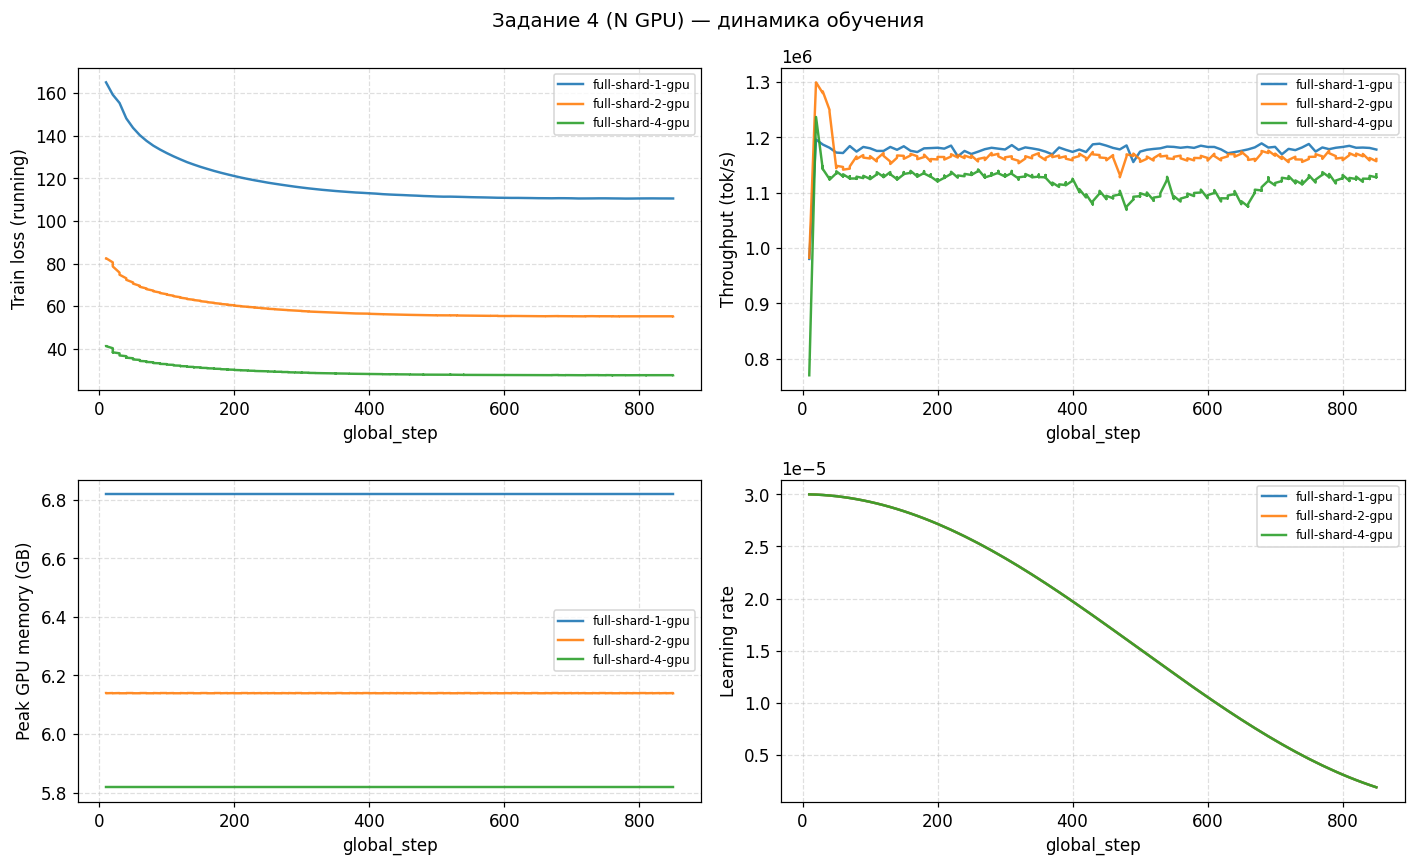

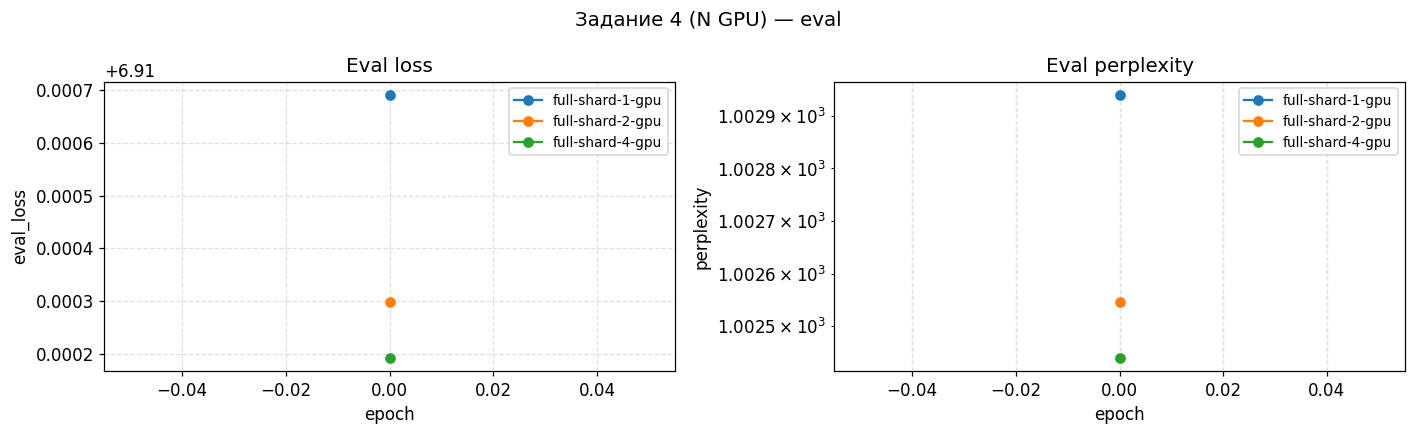

In [16]:
runs_t4 = load_runs({
    'full-shard-1-gpu':        'fsdp-full-shard-1-gpu.log',
    'full-shard-2-gpu':       'fsdp-full-shard-2-gpu.log',
    'full-shard-4-gpu':       'fsdp-full-shard-4-gpu.log',
})
plot_dynamics(runs_t4, title_prefix='Задание 4 (N GPU)', smooth=3)
plot_eval(runs_t4, title_prefix='Задание 4 (N GPU)')

| N GPU | Throughput total (tok/s)  | Throughput per GPU (tok/s) | Peak mem/GPU (GB) | Val PPL |
|---|---|---|---|---|
| 1 | 1179112.3 | 1179112.3 | 6.8183459840000005 | 1002.9402965265492 |
| 2 | 1167765.8 | 583882.9| 6.1391851520000005 | 1002.5458267812967 |
| 4 | 1119692.4 | 279923.1 | 5.818087424000001 | 1002.4392270530501 |
### 4.A (3 балла)
При идеальном масштабировании throughput per GPU не падает с ростом N. Постройте график throughput per GPU vs N. Вычислите scaling efficiency для N=2 и N=4:

η(N) = throughput_per_gpu(N) / throughput_per_gpu(1)
Объясните получившиеся значения.

#### Ответ
Вычисление η(N):
Throughput per GPU при N=1: 1 179 112.3 tok/s (базовое значение).

η(2) = 583 882.9 / 1 179 112.3 ≈ 0.495 (≈49.5%)
η(4) = 279 923.1 / 1 179 112.3 ≈ 0.237 (≈23.7%)

Что мы видим. Идеальное масштабирование означало бы η(N) = 1 для всех N - то есть суммарный throughput рос бы линейно: ~1.18M → ~2.36M → ~4.72M tok/s. На практике суммарный throughput почти не меняется (1.179M → 1.168M → 1.120M tok/s), а throughput per GPU падает практически пропорционально N: при удвоении числа GPU per-GPU throughput примерно делится на 2. Это очень далеко от идеала и фактически означает, что добавление GPU не ускоряет обучение вообще - мы просто размазываем ту же работу по большему числу устройств.
Почему так получилось. Главные причины:

Фиксированный глобальный батч (strong scaling без увеличения нагрузки). Если батч не масштабируется с N, то на каждом GPU остаётся всё меньше полезной работы. Время вычислений падает, а коммуникация - нет, и доля коммуникации в общем времени итерации растёт. По закону Амдала это и даёт почти горизонтальную кривую суммарного throughput.
Накладные расходы FSDP на коммуникацию. На каждом FSDP-юните выполняются all_gather параметров перед forward и backward и reduce_scatter градиентов после backward. Объём этого трафика растёт с N, и если он не успевает перекрыться вычислением, GPU простаивают.
Маленькая модель. При размерах, где per-GPU вычисление занимает мало времени, любые фиксированные оверхеды (запуск ядер, синхронизации, барьеры) становятся заметными и съедают выигрыш от параллелизма.

Вывод: в этом эксперименте мы наблюдаем классический случай, когда модель слишком мала и/или батч слишком мал для имеющегося числа GPU - параллелизм даёт экономию памяти, но не ускорение. Чтобы получить разумную эффективность, нужно либо увеличить per-GPU батч (weak scaling), либо взять модель побольше, чтобы вычислительная часть доминировала над коммуникационной.


### 4.B (2 балла)
Peak mem/GPU уменьшается с ростом N. Проверьте: отношение mem(N=1) / mem(N=4) - близко ли оно к 4? Если нет - какая часть памяти не уменьшается при шардировании и почему?
#### Ответ
Проверка отношения:
mem(N=1) / mem(N=4) = 6.818 / 5.818 ≈ 1.17
Идеальное значение при полном шардировании было бы 4 (или близко к нему). Получившиеся 1.17 - очень далеко от идеала: при переходе с 1 GPU на 4 память на устройство уменьшилась всего на ~15%, тогда как "наивно" ожидалось бы уменьшение в 4 раза.
Какая часть памяти не уменьшается и почему. Пиковая память на GPU состоит из нескольких компонент, и шардирование уменьшает только часть из них:

Шардируется (масштабируется ~1/N): параметры модели, градиенты, состояния оптимизатора. Эти три компоненты в FULL_SHARD действительно делятся между N устройств.
Не шардируется (остаётся примерно постоянной):
Активации - каждый GPU обрабатывает свой микро-батч и хранит активации для своего forward-прохода целиком; шардирование параметров на это не влияет.
Временно собранные полные параметры - во время forward/backward конкретного FSDP-юнита его веса собираются all_gather'ом до полного размера на каждом GPU. То есть на пике для текущего слоя память такая же, как без шардирования (для этого слоя).
Буферы коммуникации - для all_gather/reduce_scatter нужны промежуточные тензоры, которые сами по себе занимают место.
Фоновые расходы: workspace CUDA-ядер, фрагментация аллокатора, CUDA-контекст, кэши cuDNN/cuBLAS - всё это фиксировано и от N не зависит.

Почему именно 1.17, а не, скажем, 2-3. Из результатов задачи 3 мы уже видели, что в этом запуске активации - доминирующая статья памяти (activation checkpointing давало экономию ~2.5 ГБ, а offload параметров - лишь ~0.65 ГБ). Если активации составляют большую часть пика и они не шардируются, то даже идеальное деление параметров и градиентов на 4 даёт скромный эффект: уменьшается лишь маленький "кусок пирога". Отсюда и наблюдаемые ~15% экономии вместо четырёхкратной.
Когда был бы виден эффект, близкий к 1/N. Для больших моделей, где параметры + оптимизатор + градиенты доминируют над активациями (например, миллиарды параметров и относительно короткие последовательности), отношение mem(1)/mem(N) действительно приближается к N. В нашем же эксперименте модель маленькая, а активации большие - поэтому FSDP даёт основную пользу не как способ сэкономить память на этой модели, а как инструмент для моделей, которые иначе вообще не помещаются.

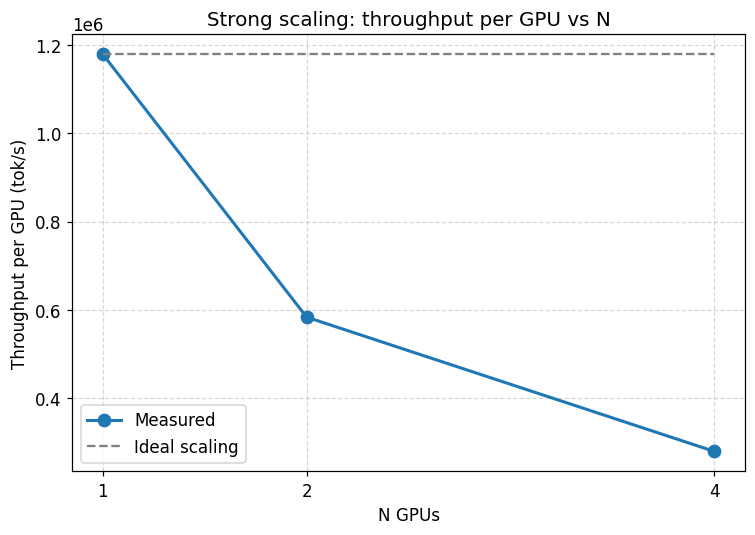

In [4]:
import matplotlib.pyplot as plt
import numpy as np
N = [1, 2, 4]
tps_per_gpu = [1179112.3, 583882.9, 279923.1]
ideal = [tps_per_gpu[0]] * 3

plt.figure(figsize=(7, 5))
plt.plot(N, tps_per_gpu, 'o-', linewidth=2, markersize=8, label='Measured')
plt.plot(N, ideal, '--', color='gray', label='Ideal scaling')
plt.xlabel('N GPUs')
plt.ylabel('Throughput per GPU (tok/s)')
plt.title('Strong scaling: throughput per GPU vs N')
plt.xticks(N)
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Доп A. Влияние размера модели на overhead шардирования

In [18]:
!bash 5_table.sh


=== 160m ===
Strategy             Peak mem/GPU (GB)      Throughput (tok/s)     Val PPL     
--------------------------------------------------------------------------------
no_shard             9.909930496000001      1524223.5              1002.6385729850238
shard_grad_op        9.252408832            1180221.6              1002.5773786505812
full_shard           9.087870464            1126067.0              1002.5118857275307

=== 410m ===
Strategy             Peak mem/GPU (GB)      Throughput (tok/s)     Val PPL     
--------------------------------------------------------------------------------
no_shard             16.376277504           775131.2               689.0163280179145
shard_grad_op        14.770013696000001     720326.3               689.1142424536133
full_shard           14.190587392000001     672742.9               689.0777693431106


=== COMPARISON 160m vs 410m ===

Strategy             Peak 160m       Peak 410m       TPS 160m        TPS 410m       
-----------------

              fsdp-160m-no_shard:  340 step-records, 1 eval-records
         fsdp-160m-shard_grad_op:  340 step-records, 1 eval-records
            fsdp-160m-full_shard:  340 step-records, 1 eval-records
              fsdp-410m-no_shard:  340 step-records, 1 eval-records
         fsdp-410m-shard_grad_op:  340 step-records, 1 eval-records
            fsdp-410m-full_shard:  340 step-records, 1 eval-records


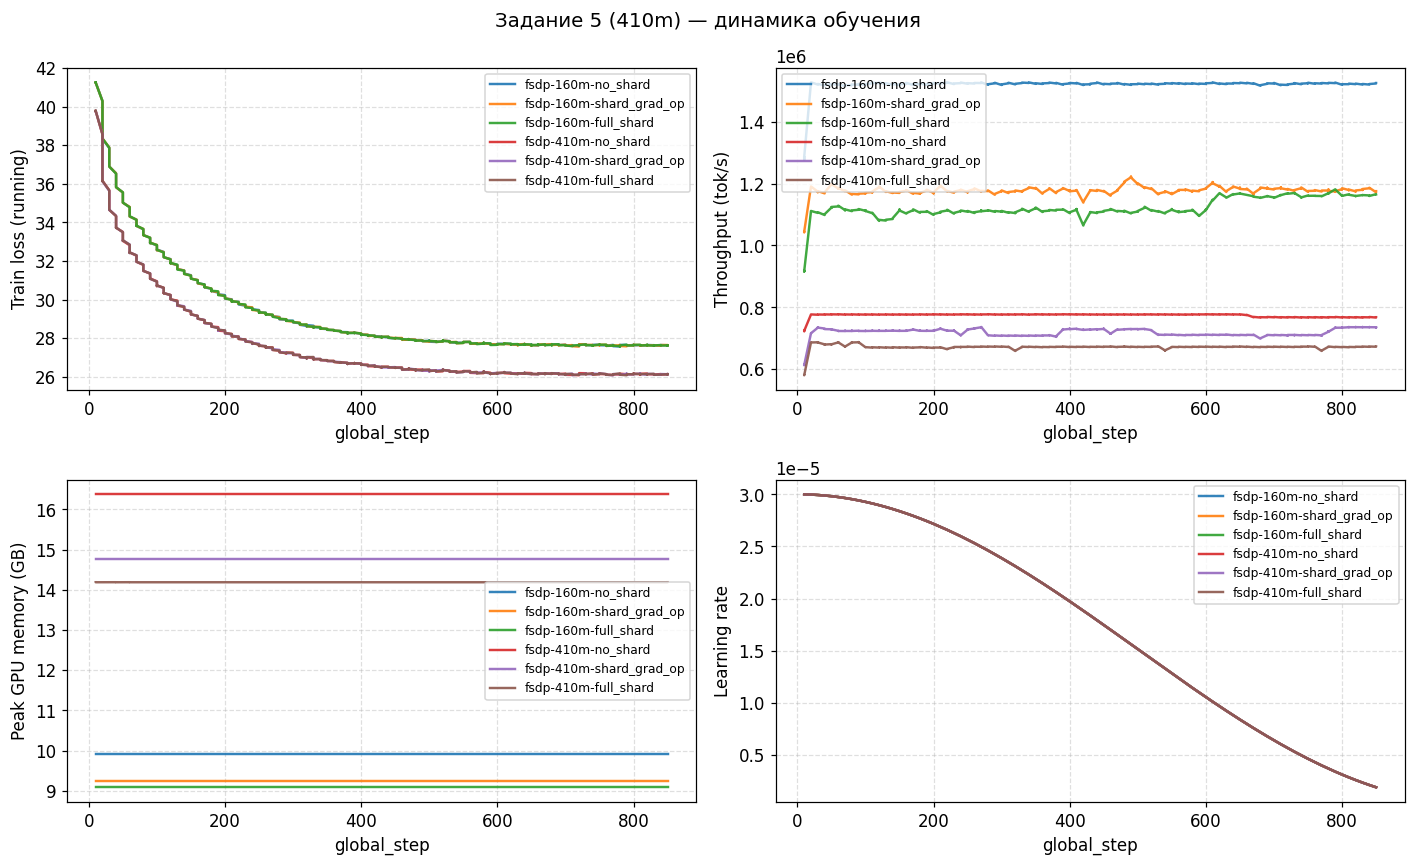

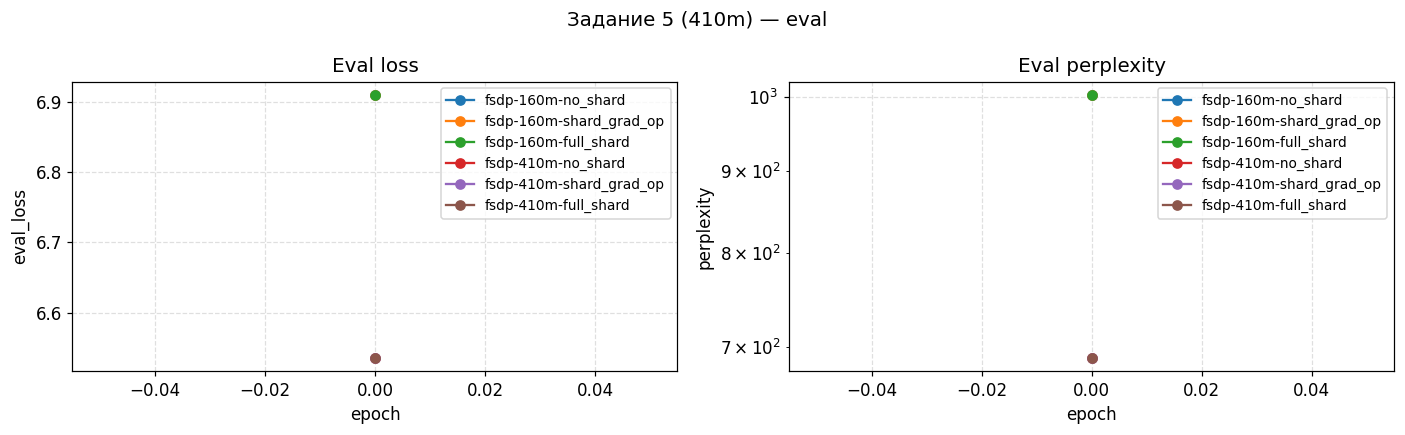

In [17]:
runs_t5 = load_runs({
    'fsdp-160m-no_shard':       'fsdp-160m-no_shard.log',
    'fsdp-160m-shard_grad_op':       'fsdp-160m-shard_grad_op.log',
    'fsdp-160m-full_shard':        'fsdp-160m-full_shard.log',
      'fsdp-410m-no_shard':       'fsdp-410m-no_shard.log',
    'fsdp-410m-shard_grad_op':       'fsdp-410m-shard_grad_op.log',
    'fsdp-410m-full_shard':        'fsdp-410m-full_shard.log',

})
plot_dynamics(runs_t5, title_prefix='Задание 5 (410m)', smooth=3)
plot_eval(runs_t5, title_prefix='Задание 5 (410m)')

Таблица для 160М
| Strategy (160M) | Peak mem/GPU (GB) | Throughput (tok/s) | Val PPL |
|---|---|---|---|
| NO_SHARD | 9.909930496000001 | 1524223.5 | 1002.6385729850238 |
| SHARD_GRAD_OP | 9.252408832 | 1180221.6 | 1002.5773786505812 |
| FULL_SHARD | 9.087870464 | 1126067.0 | 1002.5118857275307 |
  
Таблица для 410М
| Strategy (410M) | Peak mem/GPU (GB) | Throughput (tok/s) | Val PPL |
|---|---|---|---|
| NO_SHARD | 16.376277504 | 775131.2 | 689.0163280179145 |
| SHARD_GRAD_OP | 14.770013696000001 | 720326.3 | 689.1142424536133 |
| FULL_SHARD | 14.190587392000001 | 672742.9 | 689.0777693431106 |
  
Постройте два сравнительных графика:

Peak mem/GPU для трех стратегий - 160m vs 410m
Throughput для трех стратегий - 160m vs 410m
### A.A (3 балла)
Для какой модели overhead FULL_SHARD относительно (в %) больше - 160m или 410m? Объясните результат: почему размер модели влияет на относительный overhead communication при шардировании?
#### Ответ
Считаем падение throughput при NO_SHARD → FULL_SHARD:

160m: 1 524 223.5 → 1 126 067.0 tok/s
Overhead = (1 524 223.5 − 1 126 067.0) / 1 524 223.5 ≈ 26.1%
410m: 775 131.2 → 672 742.9 tok/s
Overhead = (775 131.2 − 672 742.9) / 775 131.2 ≈ 13.2%

Вывод: относительный overhead FULL_SHARD заметно больше для меньшей модели (160m) - она теряет ~26% throughput, тогда как 410m теряет лишь ~13%. То есть 160m страдает от шардирования примерно вдвое сильнее в относительных терминах.
Почему размер модели влияет на относительный overhead. Время одной итерации FSDP можно грубо разложить на две составляющие:

T_compute - время на forward + backward + optimizer step. Растёт с размером модели примерно как O(P), где P - число параметров (для трансформера при фиксированной длине контекста).
T_comm - время на all_gather параметров (×2: forward и backward) и reduce_scatter градиентов. Объём передаваемых данных тоже пропорционален P, но идёт через сеть/NVLink с фиксированной пропускной способностью.

Относительный overhead определяется отношением T_comm / T_compute. Ключевой момент в том, что арифметическая интенсивность (FLOPs на байт переданных данных) у крупных моделей выше: GPU успевает сделать больше полезных вычислений на каждый байт обмена с другими rank'ами. Конкретные механизмы:

Overlap коммуникации и вычислений работает лучше для больших моделей. FSDP старается префетчить all_gather следующего слоя, пока считается текущий. Если T_compute текущего слоя достаточно велико, коммуникация полностью прячется за вычислением. У 160m forward по слою быстрый, и all_gather не успевает спрятаться - пузыри простоя видны напрямую. У 410m слои "толще", вычисление длиннее, и коммуникация лучше перекрывается.
Фиксированные оверхеды размазываются по большей работе. Запуск CUDA-ядер, барьеры синхронизации, инициализация коллективов NCCL - это constant cost на каждый FSDP-юнит, не зависящий от его размера. У 160m доля этих расходов в общем времени итерации больше.
GPU лучше утилизированы на крупных матрицах. Для маленькой модели GEMM-ядра могут не насыщать SMs, и compute идёт неэффективно - что ещё сильнее увеличивает относительную долю коммуникации.

Это общий принцип распределённого обучения: FSDP "окупается" тем лучше, чем больше модель. Для маленьких моделей шардирование часто даёт двузначные проценты замедления при минимальной пользе по памяти, а для больших - становится практически бесплатным.
Любопытная деталь: переход NO_SHARD → SHARD_GRAD_OP уже даёт большую часть overhead'а (для 160m: 1524K → 1180K, потеря ~22.6%), а добавление шардирования параметров (SHARD_GRAD_OP → FULL_SHARD) стоит относительно мало (1180K → 1126K, ещё ~4.6%). Это согласуется с устройством FSDP: основная коммуникационная стоимость - reduce_scatter градиентов, который добавляется уже на стадии SHARD_GRAD_OP; дополнительный all_gather параметров на forward вносит меньший вклад.
### A.B (3 балла)
Экономия памяти при переходе NO_SHARD -> FULL_SHARD на 4 GPU: она больше для 410m или для 160m? Соответствует ли отношение экономии соотношению размеров моделей? Если нет - что еще влияет на потребление памяти помимо model states?
#### Ответ
Считаем абсолютную и относительную экономию:

160m: 9.910 → 9.088 ГБ
Экономия абсолютная: ~0.822 ГБ
Экономия относительная: ~8.3%
410m: 16.376 → 14.191 ГБ
Экономия абсолютная: ~2.186 ГБ
Экономия относительная: ~13.4%

Экономия больше для 410m - и в абсолюте (2.19 ГБ против 0.82 ГБ), и в процентах (13.4% против 8.3%). Это интуитивно: у большей модели больше параметров и состояний оптимизатора, которые есть что шардировать.
Соответствует ли отношение экономии соотношению размеров? Проверим:

Отношение размеров моделей: 410M / 160M ≈ 2.56
Отношение абсолютных экономий: 2.186 / 0.822 ≈ 2.66

Здесь - довольно близко: отношения почти совпадают. Это разумно, потому что экономия от шардирования в первую очередь приходит от model states (параметры + градиенты + оптимизатор), а они масштабируются примерно линейно с числом параметров. Грубая оценка: при FULL_SHARD на 4 GPU параметры + градиенты + Adam-моменты экономят (1 − 1/4) = 0.75 от своего полного размера. Для модели 410M в fp32 это ~16 × 0.75 × (3/4 от полного объёма model states, который ~16 ГБ суммарно) - порядок ~2 ГБ, что совпадает с замером.
Но если мы возьмём не абсолютную экономию, а относительную (в процентах от пика), то картина выходит интереснее. У 410m экономится 13.4% от пика, а у 160m - только 8.3%. То есть доля model states в пиковой памяти выше у большой модели, и FSDP заметнее на ней сказывается. Это и отвечает на вторую часть вопроса.
Что ещё влияет на потребление памяти помимо model states. Пиковая память - это сумма нескольких компонент, и шардируются только некоторые:

Шардируется (∝ 1/N): параметры, градиенты, состояния оптимизатора.
Не шардируется:
Активации - зависят от размера батча, длины последовательности и ширины модели (hidden size), но не от глубины напрямую. Каждый GPU держит активации своего микро-батча целиком.
Временно собранные полные параметры текущего FSDP-юнита - на пике forward/backward слоя его веса собираются all_gather'ом до полного размера.
Буферы коммуникации для all_gather/reduce_scatter.
Workspace CUDA-ядер, фрагментация аллокатора, CUDA-контекст, кэши cuDNN/cuBLAS - фиксированные расходы.

Ключевое наблюдение: активации часто доминируют в пике, особенно при больших batch × seq_len и без activation checkpointing. Именно поэтому экономия даже 75% от размера model states превращается в скромные 8–13% от пика - большая часть пирога просто не подвержена шардированию.
Можно прикинуть это явно. У 160m суммарный объём model states (params + grads + Adam в fp32) ≈ 160M × 16 байт ≈ 2.56 ГБ. При FULL_SHARD на 4 GPU экономия по теории ≈ 0.75 × 2.56 ≈ 1.9 ГБ. Но мы видим только 0.82 ГБ - разница уходит на временный all_gather (полный размер слоя на пике), коммуникационные буферы и фрагментацию. У 410m: model states ≈ 6.56 ГБ, теоретическая экономия 0.75 × 6.56 ≈ 4.9 ГБ, на практике ~2.2 ГБ - те же самые "невидимые" расходы съедают часть выгоды, но в абсолюте экономия всё равно больше.
Итог: отношение экономий примерно соответствует отношению размеров моделей в абсолютном выражении (это эффект масштабирования model states), но в относительном - для большой модели шардирование выгоднее. На общую картину влияют активации и неизбежные оверхеды FSDP, которые шардированием не убираются и определяют, какая доля пика "поддаётся" оптимизации.

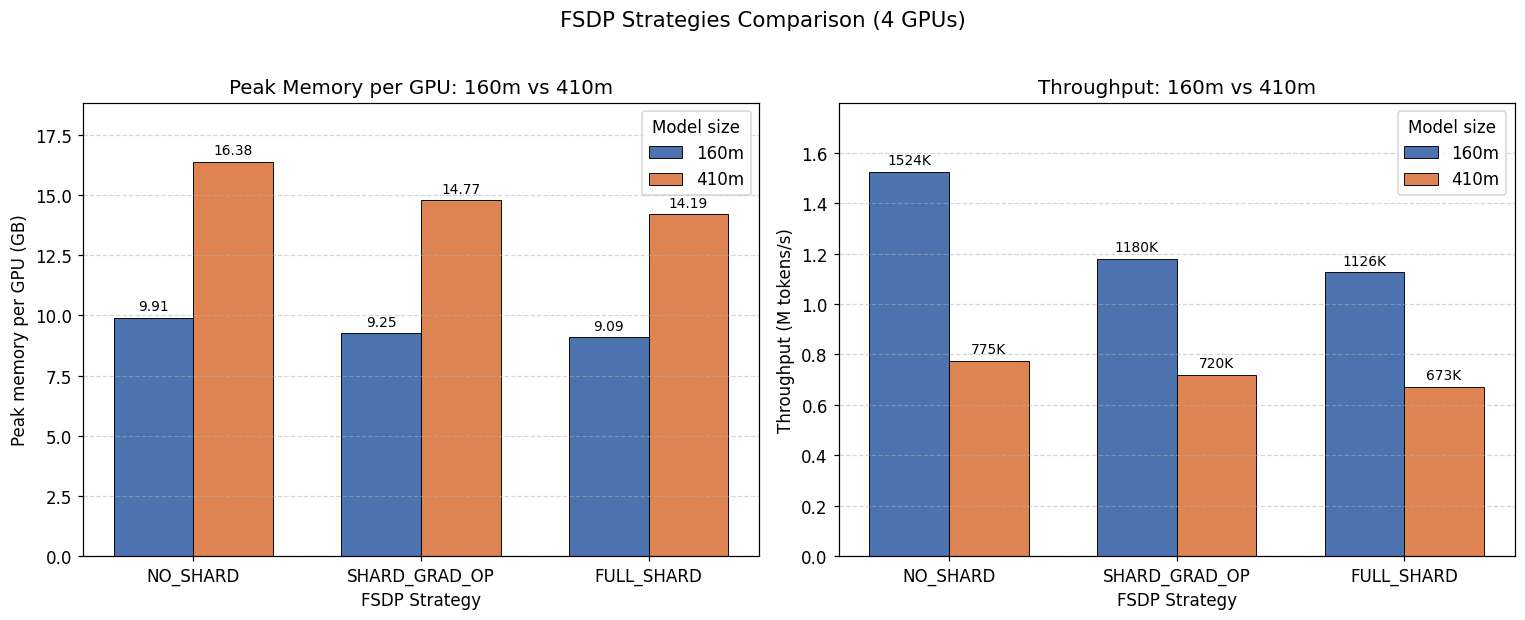

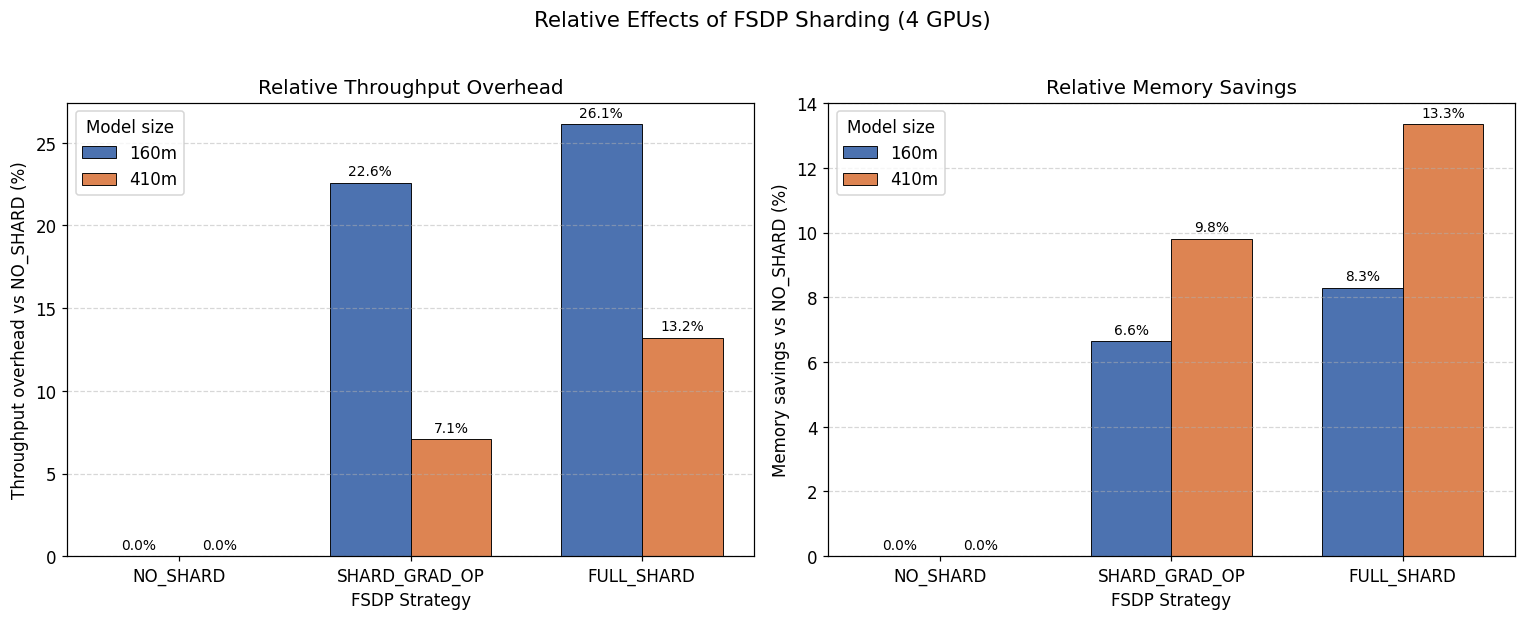

In [1]:
import matplotlib.pyplot as plt
import numpy as np

strategies = ['NO_SHARD', 'SHARD_GRAD_OP', 'FULL_SHARD']

peak_mem_160m = [9.909930496, 9.252408832, 9.087870464]
peak_mem_410m = [16.376277504, 14.770013696, 14.190587392]

throughput_160m = [1524223.5, 1180221.6, 1126067.0]
throughput_410m = [775131.2, 720326.3, 672742.9]

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 110,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

x = np.arange(len(strategies))
width = 0.35

color_160 = '#4C72B0'
color_410 = '#DD8452'

# --- График 1: Peak Memory ---
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, peak_mem_160m, width, label='160m',
                color=color_160, edgecolor='black', linewidth=0.6)
bars2 = ax1.bar(x + width/2, peak_mem_410m, width, label='410m',
                color=color_410, edgecolor='black', linewidth=0.6)

ax1.set_xlabel('FSDP Strategy')
ax1.set_ylabel('Peak memory per GPU (GB)')
ax1.set_title('Peak Memory per GPU: 160m vs 410m')
ax1.set_xticks(x)
ax1.set_xticklabels(strategies)
ax1.legend(title='Model size')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_ylim(0, max(peak_mem_410m) * 1.15)

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax1.annotate(f'{h:.2f}',
                     xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 3), textcoords='offset points',
                     ha='center', va='bottom', fontsize=9)

# --- График 2: Throughput ---
ax2 = axes[1]
tps_160m_M = [t / 1e6 for t in throughput_160m]
tps_410m_M = [t / 1e6 for t in throughput_410m]

bars3 = ax2.bar(x - width/2, tps_160m_M, width, label='160m',
                color=color_160, edgecolor='black', linewidth=0.6)
bars4 = ax2.bar(x + width/2, tps_410m_M, width, label='410m',
                color=color_410, edgecolor='black', linewidth=0.6)

ax2.set_xlabel('FSDP Strategy')
ax2.set_ylabel('Throughput (M tokens/s)')
ax2.set_title('Throughput: 160m vs 410m')
ax2.set_xticks(x)
ax2.set_xticklabels(strategies)
ax2.legend(title='Model size')
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.set_ylim(0, max(tps_160m_M) * 1.18)

for bars, raw in ((bars3, throughput_160m), (bars4, throughput_410m)):
    for bar, val in zip(bars, raw):
        h = bar.get_height()
        ax2.annotate(f'{val/1e3:.0f}K',
                     xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 3), textcoords='offset points',
                     ha='center', va='bottom', fontsize=9)

plt.suptitle('FSDP Strategies Comparison (4 GPUs)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# --- Дополнительные графики: относительный overhead и экономия памяти ---
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5.5))

overhead_160m = [(throughput_160m[0] - t) / throughput_160m[0] * 100 for t in throughput_160m]
overhead_410m = [(throughput_410m[0] - t) / throughput_410m[0] * 100 for t in throughput_410m]

ax3 = axes2[0]
b1 = ax3.bar(x - width/2, overhead_160m, width, label='160m',
             color=color_160, edgecolor='black', linewidth=0.6)
b2 = ax3.bar(x + width/2, overhead_410m, width, label='410m',
             color=color_410, edgecolor='black', linewidth=0.6)
ax3.set_xlabel('FSDP Strategy')
ax3.set_ylabel('Throughput overhead vs NO_SHARD (%)')
ax3.set_title('Relative Throughput Overhead')
ax3.set_xticks(x)
ax3.set_xticklabels(strategies)
ax3.legend(title='Model size')
ax3.grid(axis='y', linestyle='--', alpha=0.5)
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax3.annotate(f'{h:.1f}%',
                     xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 3), textcoords='offset points',
                     ha='center', va='bottom', fontsize=9)

savings_160m = [(peak_mem_160m[0] - m) / peak_mem_160m[0] * 100 for m in peak_mem_160m]
savings_410m = [(peak_mem_410m[0] - m) / peak_mem_410m[0] * 100 for m in peak_mem_410m]

ax4 = axes2[1]
b3 = ax4.bar(x - width/2, savings_160m, width, label='160m',
             color=color_160, edgecolor='black', linewidth=0.6)
b4 = ax4.bar(x + width/2, savings_410m, width, label='410m',
             color=color_410, edgecolor='black', linewidth=0.6)
ax4.set_xlabel('FSDP Strategy')
ax4.set_ylabel('Memory savings vs NO_SHARD (%)')
ax4.set_title('Relative Memory Savings')
ax4.set_xticks(x)
ax4.set_xticklabels(strategies)
ax4.legend(title='Model size')
ax4.grid(axis='y', linestyle='--', alpha=0.5)
for bars in (b3, b4):
    for bar in bars:
        h = bar.get_height()
        ax4.annotate(f'{h:.1f}%',
                     xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 3), textcoords='offset points',
                     ha='center', va='bottom', fontsize=9)

plt.suptitle('Relative Effects of FSDP Sharding (4 GPUs)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()